In [2]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.fetch_data import load_all_raw, STOCK_UNIVERSE, SECTOR_MAP
from src.data.preprocess import preprocess_all
from src.data.screening import sector_momentum
from src.analysis.volatility import volatility_summary
from src.analysis.trend_analysis import trend_summary
#from src.analysis.correlation import return_correlation_matrix, correlation_weights, low_correlation_pairs
from src.portfolio.allocation import build_portfolio

plt.style.use("seaborn-v0_8-whitegrid")
print("Imports OK")

Imports OK


In [3]:
raw = load_all_raw()
processed = preprocess_all(raw, save=False)
print(f"Loaded {len(processed)} stocks")

INFO | Preprocessing HDFCBANK.NS …
INFO | Preprocessing ICICIBANK.NS …
INFO | Preprocessing TCS.NS …
INFO | Preprocessing INFY.NS …
INFO | Preprocessing SUNPHARMA.NS …
INFO | Preprocessing DRREDDY.NS …
INFO | Preprocessing HINDUNILVR.NS …
INFO | Preprocessing ITC.NS …
INFO | Preprocessing MARUTI.NS …
INFO | Preprocessing complete.


Loaded 9 stocks


In [4]:
vol_df = volatility_summary(raw)
print("── Volatility Summary ──")
print(vol_df.to_string())

INFO | Volatility summary saved to /workspaces/time-series-stock-analysis/deliverables/task4_analysis/volatility_metrics.csv


── Volatility Summary ──
               Rolling_Vol_Ann  GARCH_FcstVol  Sharpe_Approx
Ticker                                                      
HDFCBANK.NS            11.4923        14.8838         0.3692
ICICIBANK.NS           11.0973        15.3952         0.8995
TCS.NS                 13.7306        19.6103         0.2127
INFY.NS                19.2927        24.1156         0.3214
SUNPHARMA.NS           15.0668        17.4921         1.0883
DRREDDY.NS             11.7071        19.5703         0.2052
HINDUNILVR.NS          19.2842        18.3553         0.0428
ITC.NS                  8.5203        15.9385         0.8948
MARUTI.NS              14.6700        18.5361         0.7177


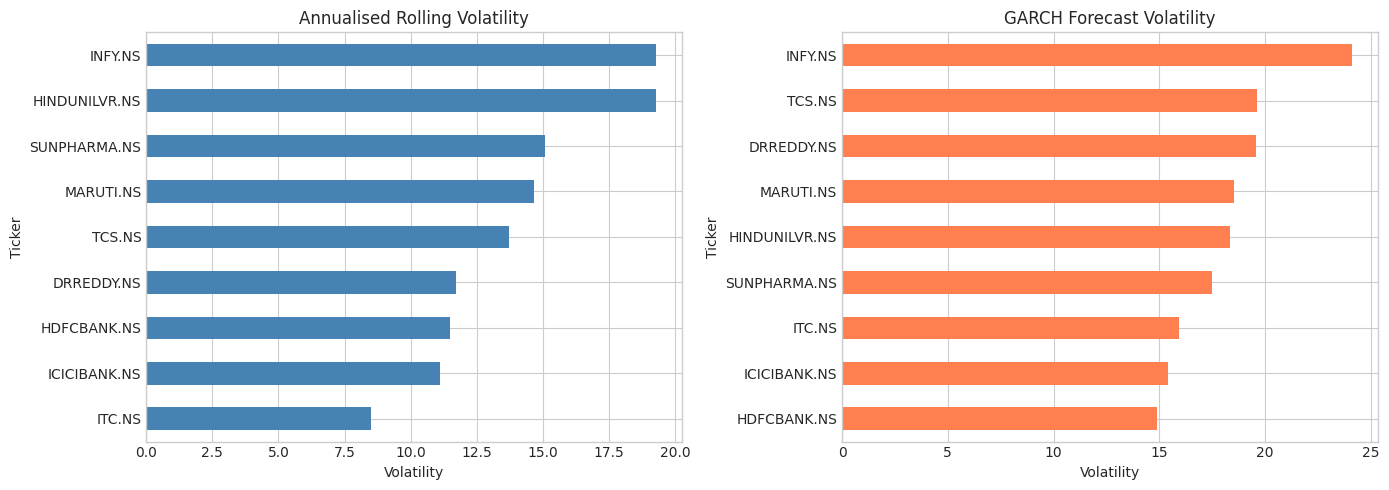

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vol_df["Rolling_Vol_Ann"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Annualised Rolling Volatility")
axes[0].set_xlabel("Volatility")

vol_df["GARCH_FcstVol"].sort_values().plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("GARCH Forecast Volatility")
axes[1].set_xlabel("Volatility")

plt.tight_layout()
plt.show()

In [6]:
trend_df = trend_summary(raw)
print("── Trend Summary ──")
print(trend_df.to_string())

INFO | Trend summary saved to /workspaces/time-series-stock-analysis/deliverables/task4_analysis/trend_metrics.csv


── Trend Summary ──
               Trend_Strength Trend_Direction
Ticker                                       
HDFCBANK.NS            0.8459          Upward
ICICIBANK.NS           0.9784          Upward
TCS.NS                 0.4891        Downward
INFY.NS                0.3261          Upward
SUNPHARMA.NS           0.9246          Upward
DRREDDY.NS             0.8494          Upward
HINDUNILVR.NS          0.4486        Downward
ITC.NS                 0.9426        Downward
MARUTI.NS              0.9043          Upward


In [ ]:
from pathlib import Path

mc_path = Path("..") / "results" / "metrics" / "model_comparison.csv"

if mc_path.exists():
    mc = pd.read_csv(mc_path)
    print("── Full Model Comparison ──")
    print(mc.to_string())
else:
    print("model_comparison.csv not found.")
    print("Run individual model notebooks first, or run:")
    print('  python main_pipeline.py --task 3')
    mc = None

In [ ]:
if mc is not None:
    avg = mc.groupby("Model")[["RMSE", "MAPE", "DirAcc"]].mean().round(4)
    print("\n── Average Metrics by Model ──")
    print(avg.to_string())
    print(f"\nBest model by MAPE: {avg['MAPE'].idxmin()}")
    print(f"Best model by DirAcc: {avg['DirAcc'].idxmax()}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for i, metric in enumerate(["MAPE", "RMSE", "DirAcc"]):
        ax = axes[i]
        mc.pivot_table(values=metric, index="Ticker", columns="Model").plot(
            kind="bar", ax=ax, rot=30
        )
        ax.set_title(metric)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=8)
    plt.suptitle("Model Comparison Across Stocks", fontsize=14)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    colors = ["#4A90D9", "#F5A623", "#7B68EE", "#20B2AA", "#E74C3C"]
    for i, metric in enumerate(["MAPE", "RMSE", "DirAcc"]):
        avg[metric].plot(kind="bar", ax=axes[i], color=colors[:len(avg)])
        axes[i].set_title(f"Avg {metric}")
        axes[i].tick_params(axis="x", rotation=30)
    plt.suptitle("Average Model Performance", fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
from src.models.arima import run_arima_pipeline

arima_preds, arima_fc, arima_met = run_arima_pipeline(processed, n_forecast=5)

current_prices = {}
for ticker, df in raw.items():
    close = df["Close"].squeeze().dropna()
    current_prices[ticker] = float(close.iloc[-1])

vol_estimates = vol_df["GARCH_FcstVol"].to_dict()

sec_mom = sector_momentum(raw, SECTOR_MAP)

tickers = list(STOCK_UNIVERSE.keys())

alloc = build_portfolio(
    tickers=tickers,
    sector_map=SECTOR_MAP,
    stock_names=STOCK_UNIVERSE,
    future_forecasts=arima_fc,
    current_prices=current_prices,
    volatility_estimates=vol_estimates,
    corr_weights=corr_w,
    sector_returns=sec_mom,
)

print("\n── Final Portfolio Allocation ──")
print(alloc.to_string())
print(f"\nTotal Deployed: ₹{alloc['Amount'].sum():,.2f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

alloc_sorted = alloc.sort_values("Weight", ascending=False)
axes[0].pie(alloc_sorted["Weight"], labels=alloc_sorted["Name"],
            autopct="%1.1f%%", pctdistance=0.85)
axes[0].set_title("Allocation by Stock")

sector_alloc = alloc.groupby("Sector")["Amount"].sum().sort_values(ascending=False)
axes[1].bar(sector_alloc.index, sector_alloc.values, color=["#4A90D9", "#F5A623", "#2ECC71", "#E74C3C", "#9B59B6"])
axes[1].set_title("Allocation by Sector (₹)")
axes[1].set_ylabel("Amount (₹)")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Portfolio Allocation — ₹10,00,000", fontsize=14)
plt.tight_layout()
plt.show()